In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")

df=pd.read_csv(os.path.join(path,"Loan_default.csv"))

print("Path to dataset files:", path)

100%|██████████| 7.86M/7.86M [00:00<00:00, 158MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nikhil1e9/loan-default/versions/2


In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
df.shape

(255347, 18)

In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Default'].value_counts()

,count
Default,
0,225694
1,29653


# Target variable

In [11]:
df['Default'].value_counts(normalize=True) * 100


,proportion
Default,
0,88.387175
1,11.612825


<Axes: xlabel='Default', ylabel='count'>

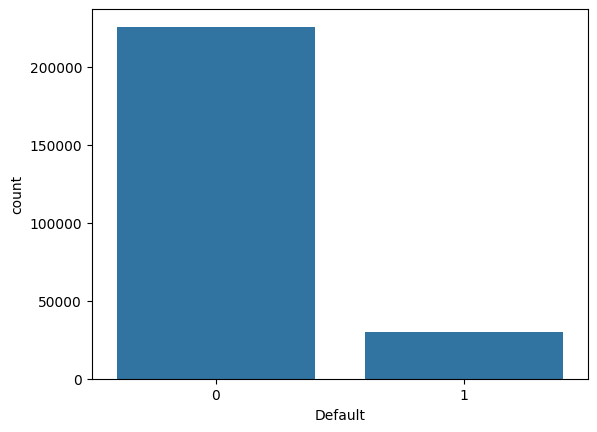

In [12]:
# Visualize it
sns.countplot(x='Default', data=df)


# distribution of numeric feature

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'LoanAmount'}>],
       [<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'MonthsEmployed'}>,
        <Axes: title={'center': 'NumCreditLines'}>],
       [<Axes: title={'center': 'InterestRate'}>,
        <Axes: title={'center': 'LoanTerm'}>,
        <Axes: title={'center': 'DTIRatio'}>],
       [<Axes: title={'center': 'Default'}>, <Axes: >, <Axes: >]],
      dtype=object)

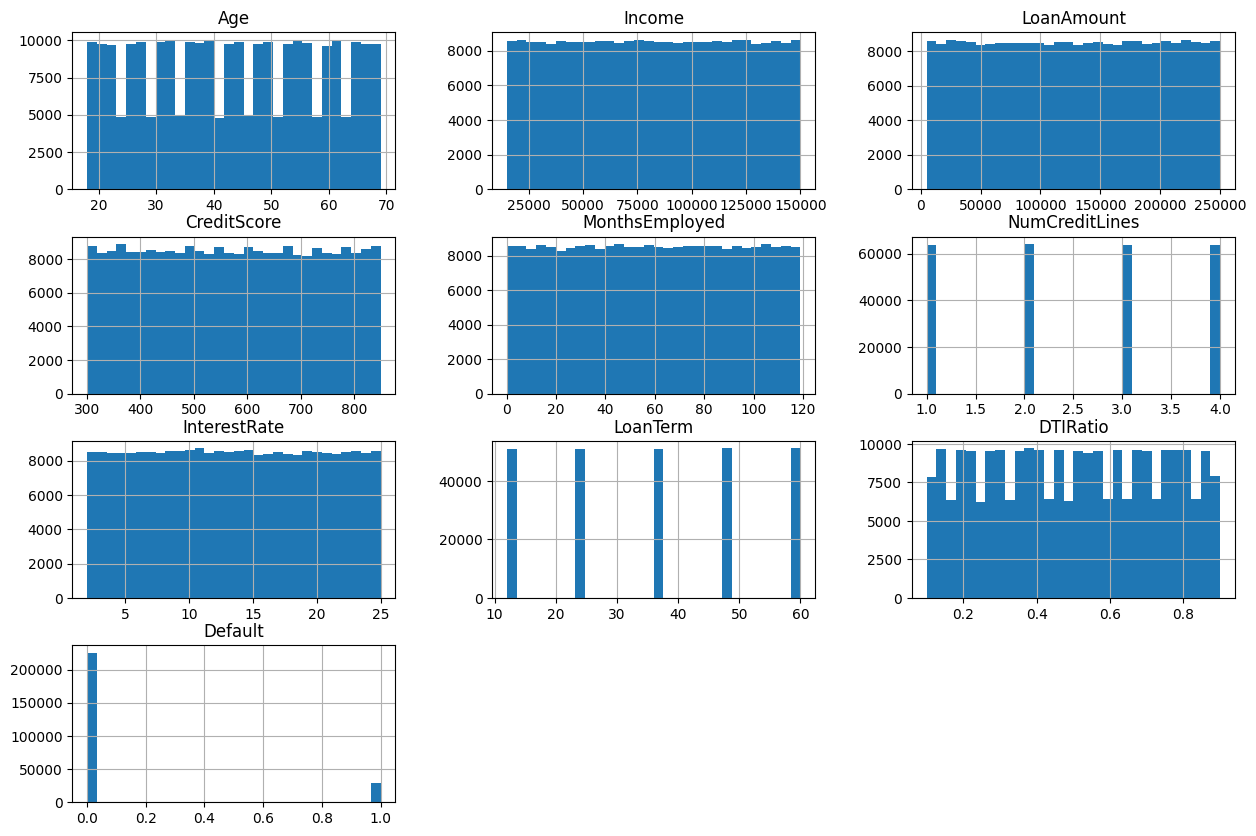

In [13]:
df.hist(figsize=(15,10), bins=30)



# box plot help to check outliers

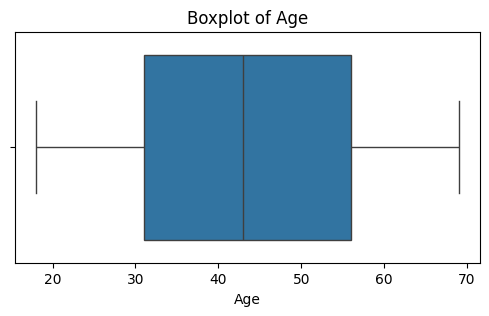

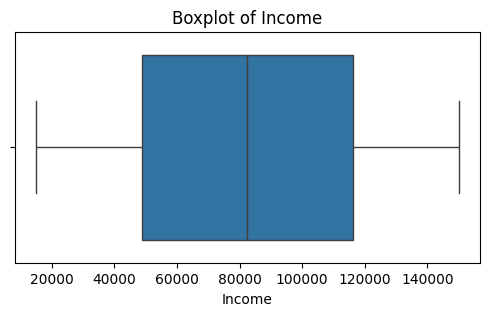

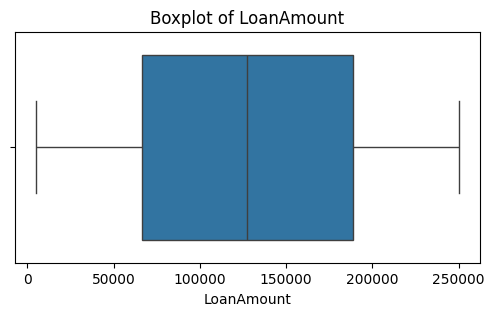

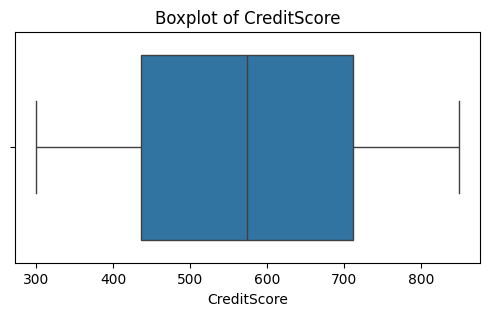

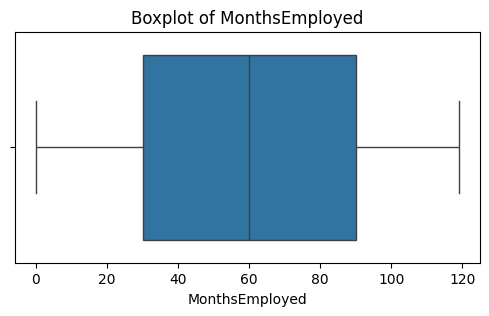

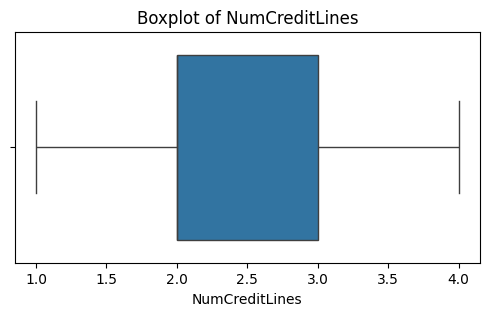

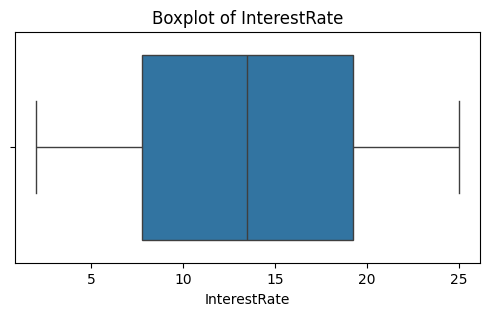

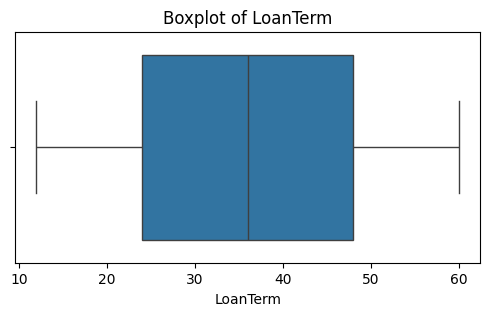

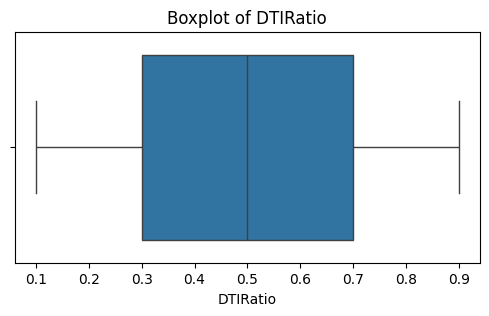

In [14]:


numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Default')

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# realtion between feature and target column

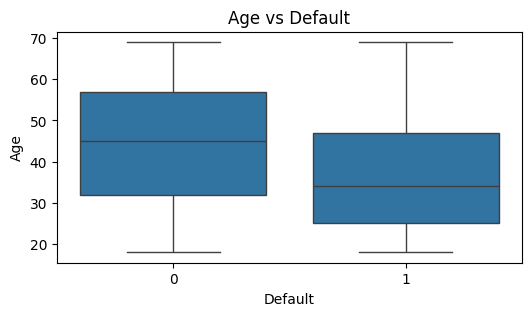

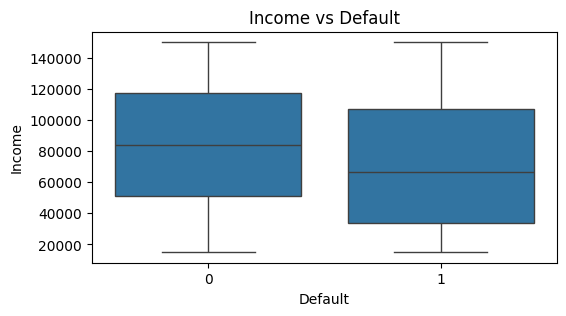

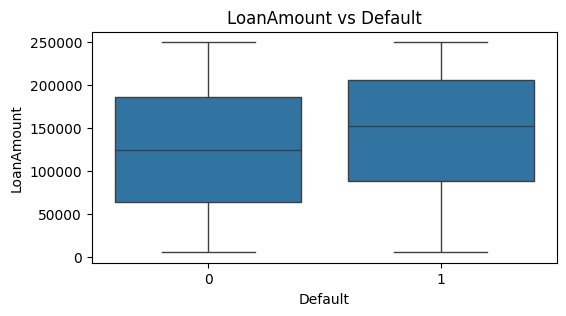

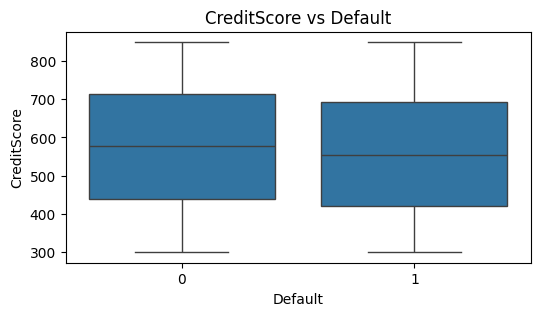

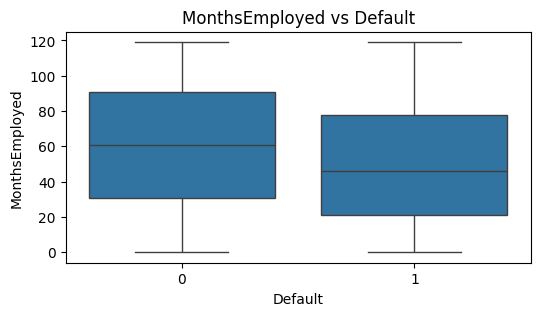

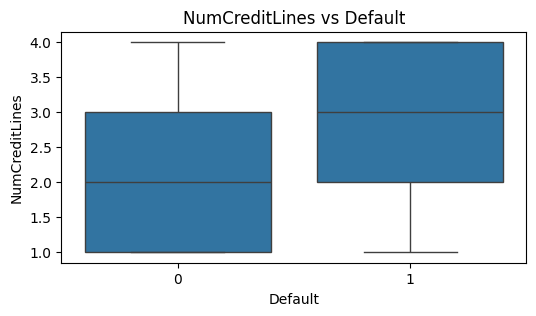

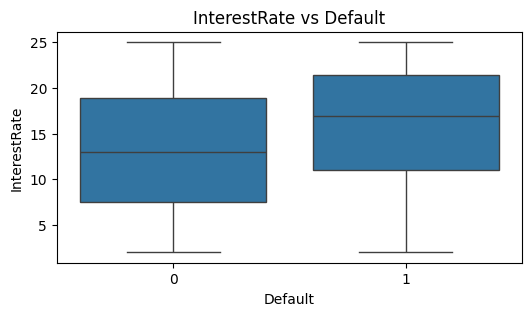

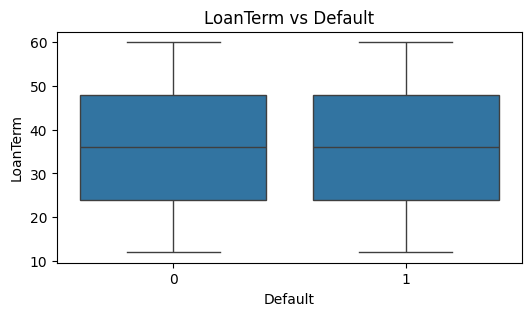

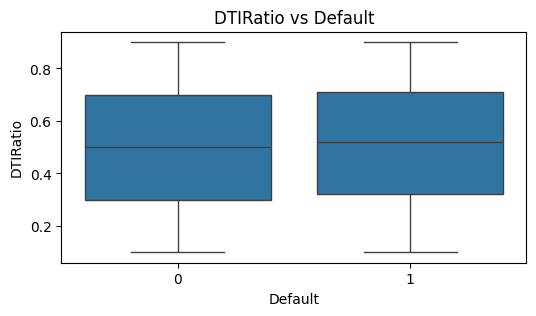

In [15]:

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df['Default'], y=df[col], data=df)
    plt.title(f'{col} vs Default')
    plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

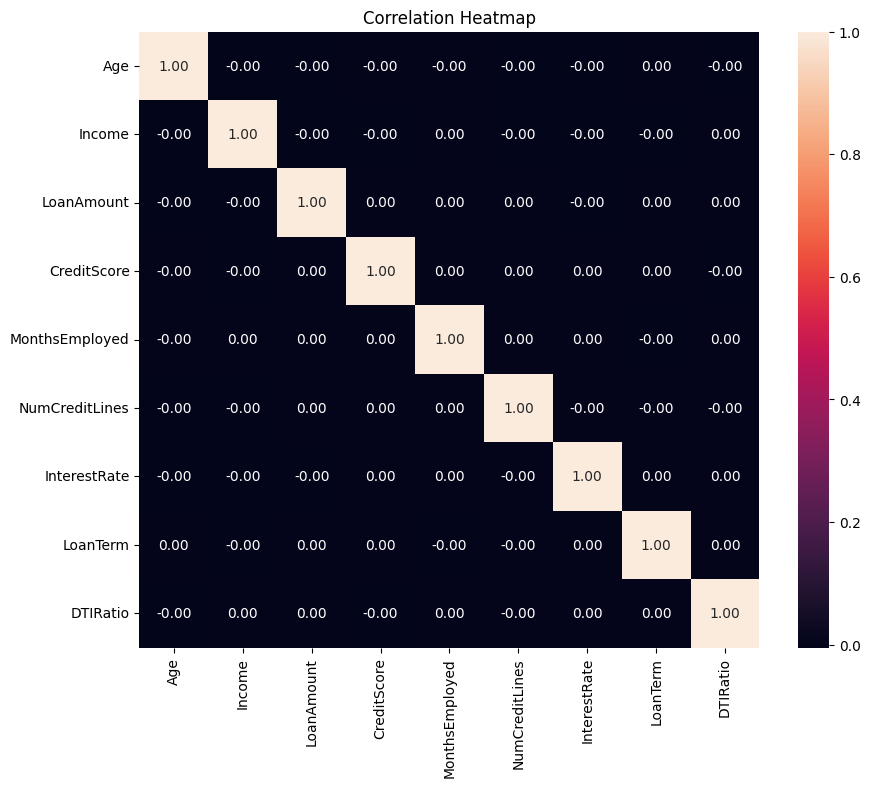

In [16]:

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True,  fmt='.2f')
plt.title('Correlation Heatmap')


# another method to check outliers (IQR)

In [17]:
numeric_cols

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'],
      dtype='object')

In [18]:

q1=df[numeric_cols].quantile(0.25)
q3=df[numeric_cols].quantile(0.75)
iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

outlier=(df[numeric_cols]<lower_bound) | (df[numeric_cols]>upper_bound)

outlier.sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


# Data cleanig

In [19]:
df


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [20]:
df_clean=df.drop(columns=['LoanID'])
df_clean

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [21]:
X=df_clean.drop(columns=['Default'])
y=df_clean['Default']

In [22]:
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                 'MonthsEmployed', 'NumCreditLines', 'InterestRate',
                 'LoanTerm', 'DTIRatio']
df[numeric_cols].skew()

,0
Age,0.000698
Income,-0.000381
LoanAmount,-0.001827
CreditScore,0.004688
MonthsEmployed,-0.002142
NumCreditLines,-0.000278
InterestRate,0.004608
LoanTerm,-0.002178
DTIRatio,-0.001499


train and split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,power_transform

numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                 'MonthsEmployed', 'NumCreditLines', 'InterestRate',
                 'LoanTerm', 'DTIRatio']
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus',
                     'HasMortgage', 'HasDependents', 'LoanPurpose',
                     'HasCoSigner']

numeric_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessing=ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])


In [25]:
preprocessing

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Income', 'LoanAmount', 'CreditScore',
                                  'MonthsEmployed', 'NumCreditLines',
                                  'InterestRate', 'LoanTerm', 'DTIRatio']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Education', 'EmploymentType',
                                  'MaritalStatus', 'HasMortgage',
                                  'HasDependents', 'LoanPurpose',
                                  'HasCoSigner'])])

# using smote and checking model in different algo

In [26]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import  LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

In [ ]:
models={
    'LogisticRegression':LogisticRegression(random_state=42),
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier':RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier':GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
  pipe=Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote', SMOTE(random_state=42)),
    ('model', model)
])
  accuracy=cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy')
  f1_macro=cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1_macro')
  recall = cross_val_score(pipe, X_train, y_train, cv=3, scoring='recall')
  print(f"model:{name}  accuracy:{accuracy.mean():.2f}  recall:{recall.mean():.2f}  f1_macro:{f1_macro.mean():.2f}")






model:LogisticRegression  accuracy:0.68  recall:0.68  f1_macro:0.56
model:DecisionTreeClassifier  accuracy:0.77  recall:0.27  f1_macro:0.54
model:RandomForestClassifier  accuracy:0.88  recall:0.09  f1_macro:0.54
model:GradientBoostingClassifier  accuracy:0.88  recall:0.15  f1_macro:0.58


In [ ]:
from xgboost import XGBClassifier
pipe=Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42))
])
accuracy=cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy')
f1_macro=cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1_macro')
recall = cross_val_score(pipe, X_train, y_train, cv=3, scoring='recall')
print(f"model:XGBClassifier  accuracy:{accuracy.mean():.2f}  recall:{recall.mean():.2f}  f1_macro:{f1_macro.mean():.2f}")



model:XGBClassifier  accuracy:0.88  recall:0.08  f1_macro:0.54


# hyperparamter tuning

In [27]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline=Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression())
])
param_distributions = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced']
}
search=RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='recall',
    random_state=42,
    verbose=3

)
search.fit(X_train, y_train)




Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END model__C=0.1, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.682 total time=  10.6s
[CV 2/3] END model__C=0.1, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.674 total time=  11.4s
[CV 3/3] END model__C=0.1, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.680 total time=   6.7s
[CV 1/3] END model__C=10, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.683 total time=   2.2s
[CV 2/3] END model__C=10, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.673 total time=   2.3s
[CV 3/3] END model__C=10, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.680 total time=   2.3s
[CV 1/3] END model__C=0.001, model__class_weight=None, model__penalty=l1, model__solver=liblinear;, score=0.687 total time=   2.7s
[CV 2/3] END model__C=0.001, model__c

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Income',
                                                                                'LoanAmount',
                                                                                'CreditScore',
                                                                                'MonthsEmployed',
                                                                                'NumCreditLines',
                                                                                'InterestRate',
                                                                                'LoanTerm',
                                                                                'DTIRatio']),
                                                                              ('categorical',
                                                                               Pipeline(steps=[('...
                                                                                'EmploymentType',
                                                                                'MaritalStatus',
                                                                                'HasMortgage',
                                                                                'HasDependents',
                                                                                'LoanPurpose',
                                                                                'HasCoSigner'])])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model', LogisticRegression())]),
                   param_distributions={'model__C': [0.001, 0.01, 0.1, 1, 10,
                                                     100],
                                        'model__class_weight': [None,
                                                                'balanced'],
                                        'model__penalty': ['l1', 'l2'],
                                        'model__solver': ['liblinear']},
                   random_state=42, scoring='recall', verbose=3)

In [28]:
print(" best param:",search.best_params_)
print("best CV f1_score:",search.best_score_)

 best param: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__class_weight': None, 'model__C': 0.001}
best CV f1_score: 0.6832433806579578


# final evalution on test data

In [29]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,recall_score,precision_score
best_pipeline=search.best_estimator_

y_pred=best_pipeline.predict(X_test)


print(f"accuracy score ->{accuracy_score(y_test,y_pred)}")
print(f"f1 score ->{f1_score(y_test,y_pred,average='macro')}")
print(f"recall score ->{recall_score(y_test,y_pred)}")
print(f"precision score ->{precision_score(y_test,y_pred)}")




accuracy score ->0.6818133270040942
f1 score ->0.5634069893929461
recall score ->0.693337420805232
precision score ->0.22176101451170088


<Axes: >

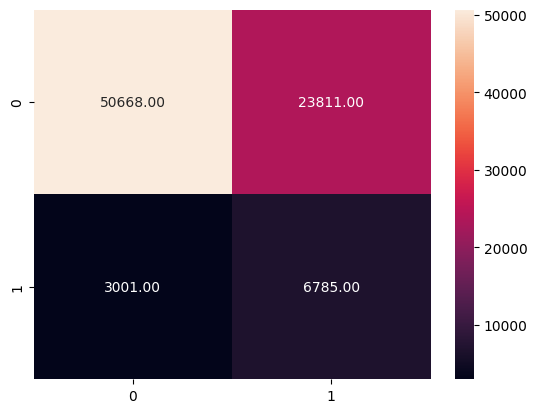

In [30]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='.2f',
            xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)

# saving the final model

In [31]:
import joblib
joblib.dump(best_pipeline,'best_model.pkl')

['best_model.pkl']